# 1000 Genomes Analysis

## Line plot of base-pair location (midpoint) vs per-tree distance, by population.

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

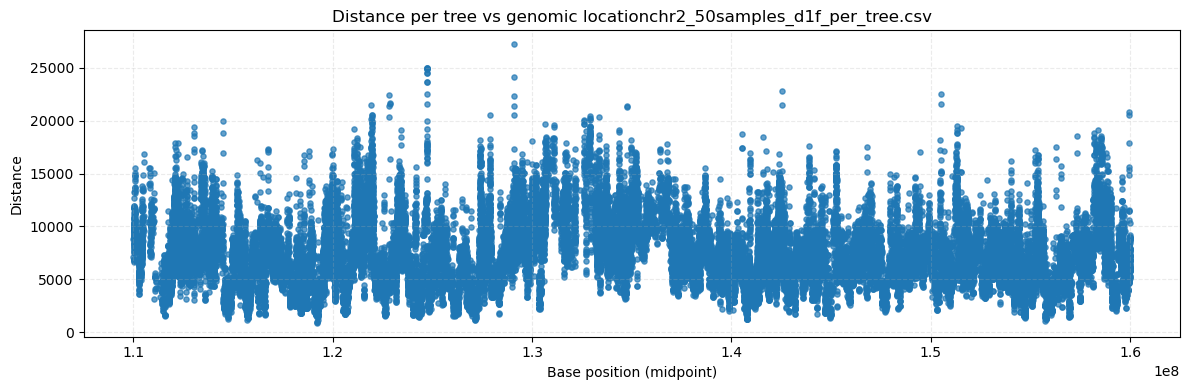

In [2]:
base = Path('.')
candidates = [ 
    base / 'chr2_50samples_dif_per_tree.csv',
    base / 'chr2_50samples_d1f_per_tree.csv',
    base / 'dif_per_tree.csv',
    base / 'd1f_per_tree.csv',
]

csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('No distance CSV found. Expected one of: ' + ', '.join(str(p.name) for p in candidates))

df = pd.read_csv(csv_path)

if 'mid' not in df.columns:
    raise KeyError("Column 'mid' not found in distance CSV.")

dist_col = None
for c in ['distance', 'd1f_distance', 'dif_distance']:
    if c in df.columns:
        dist_col = c
        break
if dist_col is None:
    raise KeyError("No distance column found. Tried: distance, d1f_distance, dif_distance")

plt.figure(figsize=(12, 4))
plt.scatter(df['mid'], df[dist_col], s=14, alpha=0.7)
plt.xlabel('Base position (midpoint)')
plt.ylabel('Distance')
plt.title(f'Distance per tree vs genomic location{csv_path.name}')
plt.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

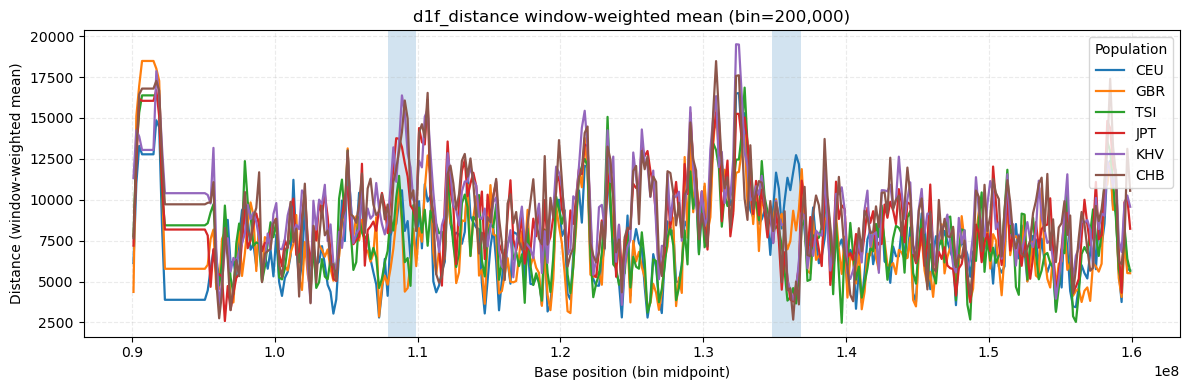

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Load CSVs (per population)
# -----------------------
base = Path(".")
results_dir = base / "results"

# NOTE: 1000 Genomes population is CEU (not CER)
target_pops = ["CEU", "GBR", "TSI", "JPT", "KHV", "CHB"]

csv_paths = {pop: results_dir / f"chr2_50samples_{pop}_d1f_per_tree.csv" for pop in target_pops}

missing = [pop for pop, p in csv_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing distance CSV(s): "
        + ", ".join(f"{pop} ({csv_paths[pop].name})" for pop in missing)
    )

# Read CSVs
dfs = {pop: pd.read_csv(path) for pop, path in csv_paths.items()}

# Detect distance column (assume consistent across files)
dist_candidates = ["distance", "d1f_distance", "dif_distance"]
dist_col = next((c for c in dist_candidates if c in next(iter(dfs.values())).columns), None)
if dist_col is None:
    raise KeyError("No distance column found. Tried: " + ", ".join(dist_candidates))

# Validate + coerce types
required_cols = ["left", "right", dist_col]
for pop, df in dfs.items():
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise KeyError(f"{pop}: missing columns {missing_cols} in {csv_paths[pop].name}")

    df = df.copy()
    for c in required_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=required_cols)
    df = df[df["right"] > df["left"]]
    df = df.sort_values("left")

    dfs[pop] = df

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 200_000

x0 = min(df["left"].min() for df in dfs.values())
x1 = max(df["right"].max() for df in dfs.values())

# snap to bin edges
x0 = (int(x0) // bin_size) * bin_size
x1 = int(np.ceil(x1 / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)

    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines)
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# LCT LP canonical site (hg38 rs4988235) ~135,851,076
pos = 135_851_076
half = 1_000_000  # +/- 1 Mb
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

for pop, df in dfs.items():
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,})")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()


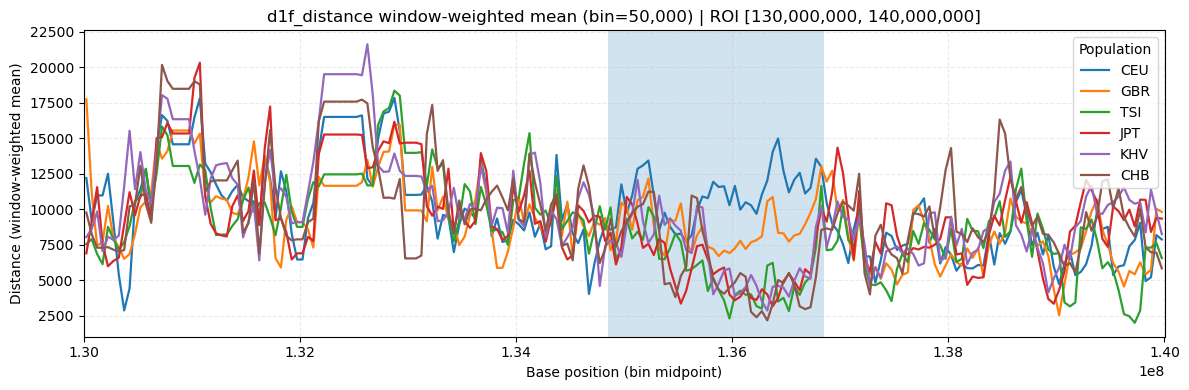

In [ ]:
# -----------------------------------
# Restrict to region of interest
# -----------------------------------
ROI_L = int(1.3e8)
ROI_R = int(1.4e8)

dfs_roi = {}
for pop, df in dfs.items():
    # keep segments that overlap the ROI at all
    d = df[(df["right"] > ROI_L) & (df["left"] < ROI_R)].copy()
    # clip segment endpoints to ROI so binning weights are correct near boundaries
    d["left"] = np.maximum(d["left"].to_numpy(dtype=float), ROI_L)
    d["right"] = np.minimum(d["right"].to_numpy(dtype=float), ROI_R)
    d = d[d["right"] > d["left"]]
    dfs_roi[pop] = d

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 50_00

# use ROI bounds (snapped to bin edges)
x0 = (ROI_L // bin_size) * bin_size
x1 = int(np.ceil(ROI_R / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines) just for ROI
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# Optional: keep the LCT highlight if it falls in ROI (it does)
pos = 135_851_076
half = 1_000_000
L = max(pos - half, ROI_L)
R = min(pos + half, ROI_R)
if L < R:
    ax.axvspan(L, R, alpha=0.2)

# EDAR highlight does NOT fall in this ROI, so we skip it automatically

for pop, df in dfs_roi.items():
    if len(df) == 0:
        continue
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlim(ROI_L, ROI_R)
ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,}) | ROI [{ROI_L:,}, {ROI_R:,}]")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()

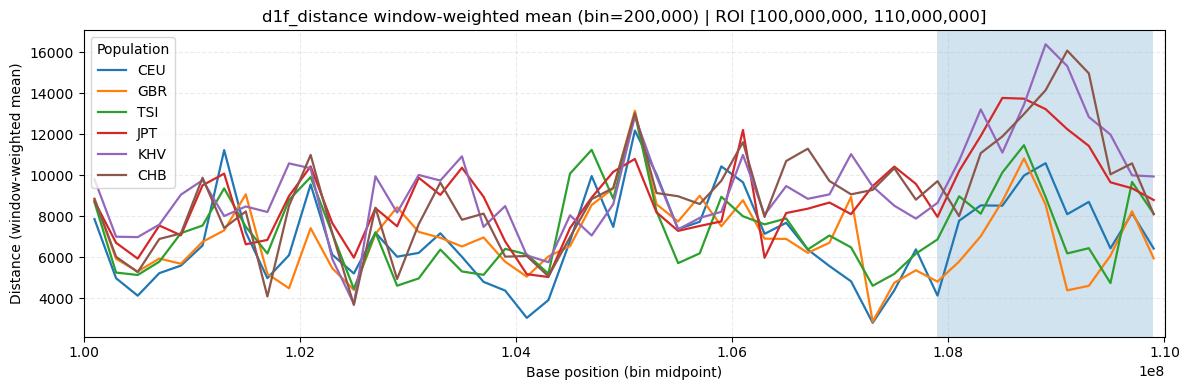

In [10]:
# -----------------------------------
# Restrict to region of interest
# -----------------------------------
ROI_L = int(1.0e8)
ROI_R = int(1.1e8)

dfs_roi = {}
for pop, df in dfs.items():
    # keep segments that overlap the ROI at all
    d = df[(df["right"] > ROI_L) & (df["left"] < ROI_R)].copy()
    # clip segment endpoints to ROI so binning weights are correct near boundaries
    d["left"] = np.maximum(d["left"].to_numpy(dtype=float), ROI_L)
    d["right"] = np.minimum(d["right"].to_numpy(dtype=float), ROI_R)
    d = d[d["right"] > d["left"]]
    dfs_roi[pop] = d

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 200_000

# use ROI bounds (snapped to bin edges)
x0 = (ROI_L // bin_size) * bin_size
x1 = int(np.ceil(ROI_R / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines) just for ROI
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# Optional: keep the EDAR highlight if it falls in ROI (it does)
pos = 108_897_145
half = 1_000_000
L = max(pos - half, ROI_L)
R = min(pos + half, ROI_R)
if L < R:
    ax.axvspan(L, R, alpha=0.2)

# EDAR highlight does NOT fall in this ROI, so we skip it automatically

for pop, df in dfs_roi.items():
    if len(df) == 0:
        continue
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlim(ROI_L, ROI_R)
ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,}) | ROI [{ROI_L:,}, {ROI_R:,}]")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()